# RetailPulse: AI-Powered Sales & Retail Analytics Platform
## Day 5 — Baseline Demand Forecasting (Prophet)

**Module:** Forecasting Models (Phase 3)

**Requirement (F-03):** Time-series forecasting with Prophet, MAPE target ≤ 12%, 30-day ahead predictions.

Uses `data/processed/prophet_ready.csv` from Day 4. This notebook:
1. Splits into train/test (last 30 days held out)
2. Fits a baseline Prophet model with weekly seasonality
3. Forecasts and evaluates against the held-out actuals (MAPE, RMSE, MAE)
4. Forecasts the true next 30 days (beyond available data) for the dashboard

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

PROCESSED_DIR = "../data/processed"
REPORTS_DIR = "../reports"

df = pd.read_csv(f"{PROCESSED_DIR}/prophet_ready.csv", parse_dates=["ds"])
print(f"Series: {len(df)} days, {df['ds'].min().date()} to {df['ds'].max().date()}")
df.tail()

Series: 730 days, 2023-01-02 to 2024-12-31


,ds,y
725,2024-12-27,285811.81
726,2024-12-28,294000.01
727,2024-12-29,333438.46
728,2024-12-30,263961.77
729,2024-12-31,316274.24


## 1. Train / Test Split

Hold out the last 30 days as a test set to measure forecast accuracy against real (already-observed) values before trusting the model on the true future.

In [2]:
HORIZON = 30
train_df = df.iloc[:-HORIZON].copy()
test_df = df.iloc[-HORIZON:].copy()

print(f"Train: {len(train_df)} days | Test: {len(test_df)} days")

Train: 700 days | Test: 30 days


## 2. Fit Baseline Prophet Model

In [3]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.05,
)
model.fit(train_df)

future = model.make_future_dataframe(periods=HORIZON)
forecast = model.predict(future)
print("Forecast generated.")
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()

07:47:31 - cmdstanpy - INFO - Chain [1] start processing


07:47:32 - cmdstanpy - INFO - Chain [1] done processing


Forecast generated.


,ds,yhat,yhat_lower,yhat_upper
725,2024-12-27,313523.870168,293603.170758,332749.796992
726,2024-12-28,317722.766577,298695.716952,337189.654417
727,2024-12-29,316859.676280,298746.611248,336931.112748
728,2024-12-30,322256.216340,303359.096667,341743.511106
729,2024-12-31,317841.202161,298251.429345,336264.337350


## 3. Evaluate Against Held-Out Test Set

In [4]:
test_forecast = forecast.set_index("ds").loc[test_df["ds"]].reset_index()
y_true = test_df["y"].values
y_pred = test_forecast["yhat"].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
# guard against divide-by-zero on zero-revenue days
nonzero_mask = y_true != 0
mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100

print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAPE: {mape:.2f}%  (target: <= 12%)")
print(f"Target met: {'YES' if mape <= 12 else 'NO — consider LSTM/hybrid ensemble (Day 6/8)'}")

MAE:  23,613.67
RMSE: 28,851.96
MAPE: 8.54%  (target: <= 12%)
Target met: YES


## 4. Forecast vs Actual (Test Window)

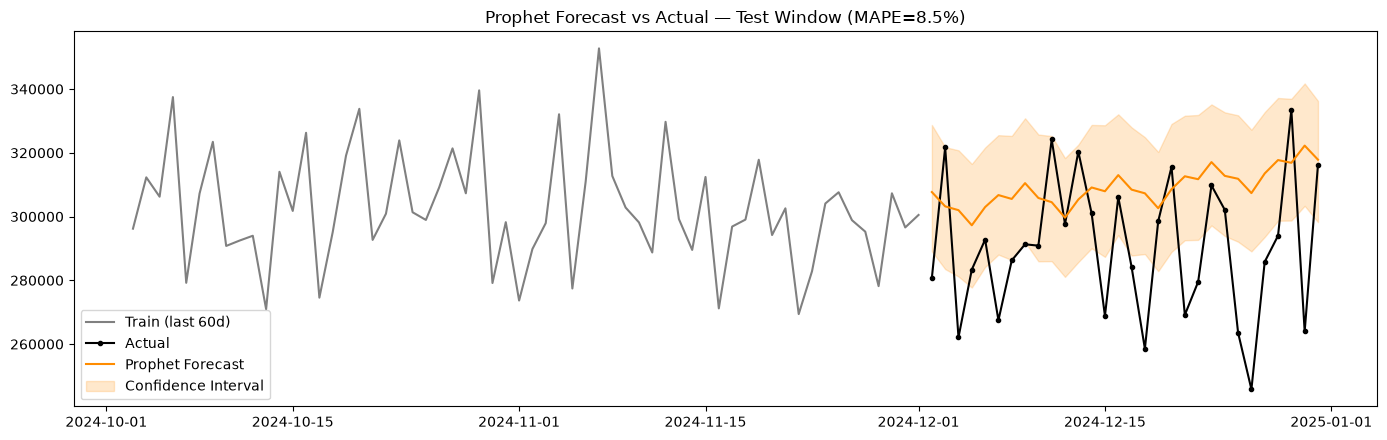

In [5]:
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(train_df["ds"].tail(60), train_df["y"].tail(60), label="Train (last 60d)", color="gray")
ax.plot(test_df["ds"], y_true, label="Actual", color="black", marker="o", markersize=3)
ax.plot(test_forecast["ds"], y_pred, label="Prophet Forecast", color="darkorange")
ax.fill_between(test_forecast["ds"], test_forecast["yhat_lower"], test_forecast["yhat_upper"],
                alpha=0.2, color="darkorange", label="Confidence Interval")
ax.set_title(f"Prophet Forecast vs Actual — Test Window (MAPE={mape:.1f}%)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day5_forecast_vs_actual.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Component Plots (Trend & Seasonality)

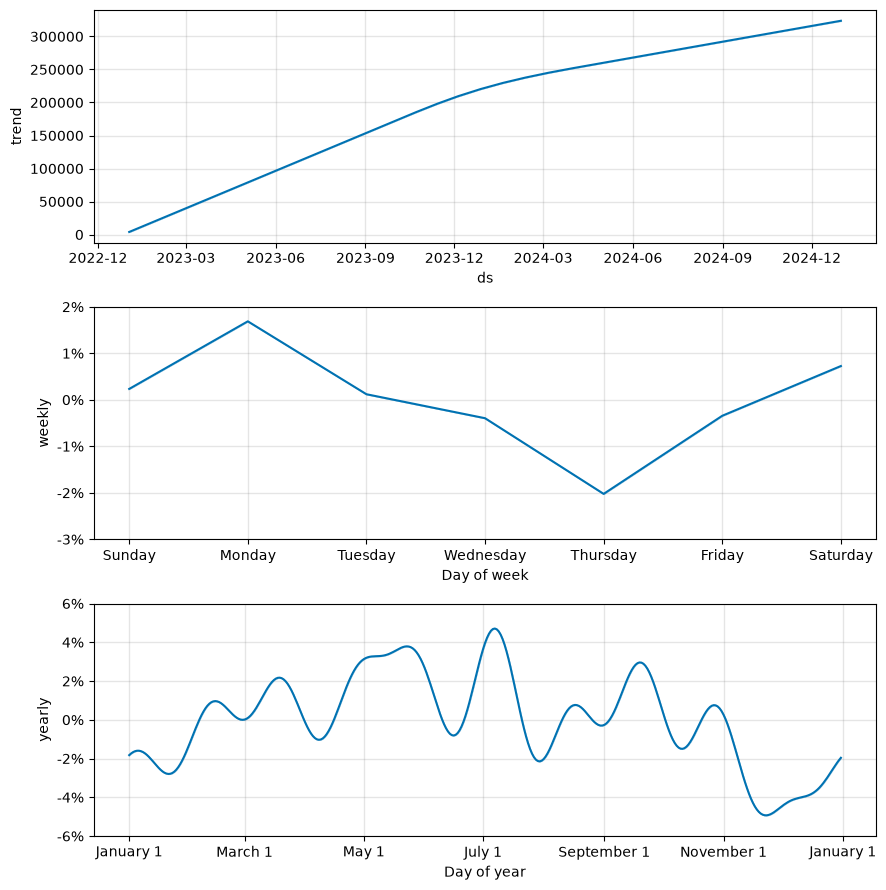

In [6]:
fig = model.plot_components(forecast)
fig.savefig(f"{REPORTS_DIR}/day5_components.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Production Forecast — Refit on Full History

Once validated, refit on the entire available series (train + test) to produce the actual next-30-day forecast the dashboard will display.

In [7]:
final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.05,
)
final_model.fit(df)

future_full = final_model.make_future_dataframe(periods=HORIZON)
forecast_full = final_model.predict(future_full)

forecast_output = forecast_full[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(HORIZON)
forecast_output.to_csv(f"{PROCESSED_DIR}/prophet_forecast_30d.csv", index=False)

print(f"Next {HORIZON}-day forecast saved.")
forecast_output.head()

07:47:32 - cmdstanpy - INFO - Chain [1] start processing


07:47:32 - cmdstanpy - INFO - Chain [1] done processing


Next 30-day forecast saved.


,ds,yhat,yhat_lower,yhat_upper
730,2025-01-01,297370.478482,277426.890590,316983.684327
731,2025-01-02,293827.568669,274886.371964,313581.232866
732,2025-01-03,301409.945177,279788.470960,321395.364778
733,2025-01-04,303613.061551,282719.917849,324000.536093
734,2025-01-05,303545.684667,284534.162633,322679.030195


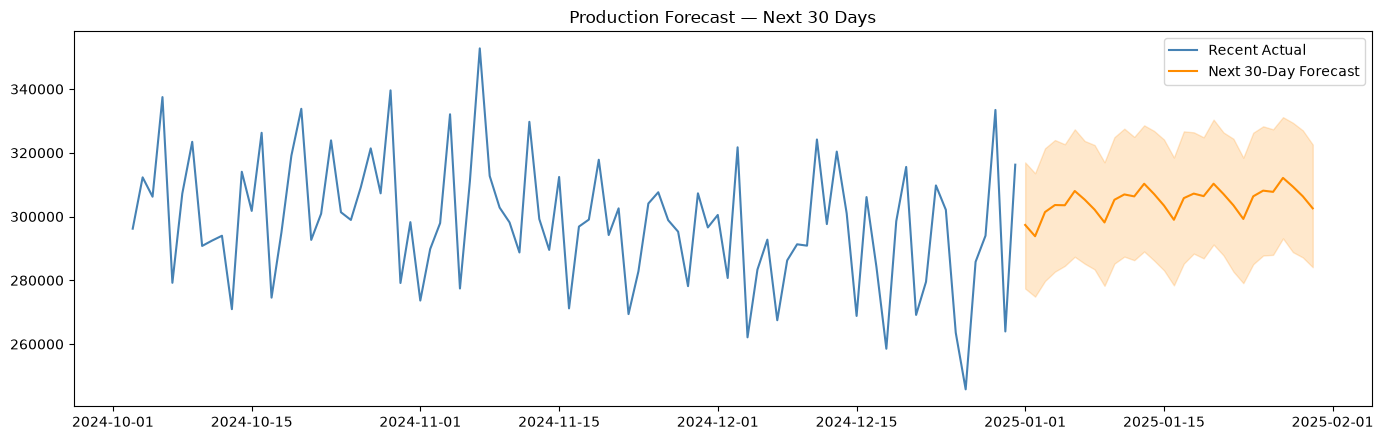

In [8]:
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(df["ds"].tail(90), df["y"].tail(90), label="Recent Actual", color="steelblue")
ax.plot(forecast_output["ds"], forecast_output["yhat"], label="Next 30-Day Forecast", color="darkorange")
ax.fill_between(forecast_output["ds"], forecast_output["yhat_lower"], forecast_output["yhat_upper"],
                alpha=0.2, color="darkorange")
ax.set_title("Production Forecast — Next 30 Days")
ax.legend()
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day5_production_forecast.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Save Model Artifact

In [9]:
import json
import os
from prophet.serialize import model_to_json

os.makedirs("../models", exist_ok=True)

with open("../models/prophet_model.json", "w") as f:
    f.write(model_to_json(final_model))

metrics = {"mape": round(float(mape), 3), "mae": round(float(mae), 2), "rmse": round(float(rmse), 2),
           "horizon_days": HORIZON, "model": "prophet_baseline"}
with open("../models/prophet_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Model + metrics saved to ../models/")
print(json.dumps(metrics, indent=2))

Model + metrics saved to ../models/
{
  "mape": 8.542,
  "mae": 23613.67,
  "rmse": 28851.96,
  "horizon_days": 30,
  "model": "prophet_baseline"
}


## 8. Day 5 Checkpoint Summary

**Outputs saved:**
- `data/processed/prophet_forecast_30d.csv` — production 30-day forecast for the dashboard
- `models/prophet_model.json` — serialized fitted model (for reuse without refitting)
- `models/prophet_metrics.json` — MAPE/MAE/RMSE on the held-out test window
- `reports/day5_forecast_vs_actual.png`, `day5_components.png`, `day5_production_forecast.png`

**Result:** see printed MAPE above vs the ≤12% target — if it isn't met, that's the exact justification for the Day 6 LSTM and Day 8 hybrid ensemble.

**Next module:** `06_lstm_forecaster` — sequence model as a second forecasting approach.